In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install umap-learn librosa -q

# Hybrid Language Music Clustering — Improved Version
**Course:** CSE 715 Neural Networks  
**Method:** Deep VAE on fused Audio (MFCC) + Lyrics (TF-IDF char n-gram) features  
**Clustering:** K-Means · Agglomerative · DBSCAN  
**Metrics:** Silhouette · Davies-Bouldin · Calinski-Harabasz · ARI (language as proxy label)


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
warnings.filterwarnings('ignore')

import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score,
    davies_bouldin_score, adjusted_rand_score
)
from sklearn.neighbors import NearestNeighbors

import umap.umap_ as umap_lib
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

2026-04-24 06:05:48.796986: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777010748.992481      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777010749.053704      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777010749.518194      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777010749.518233      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777010749.518236      55 computation_placer.cc:177] computation placer alr

Using device: cuda


## 1. Data Loading

In [8]:
# ── 1A. Lyrics datasets ───────────────────────────────────────────────────────
ds_en = pd.read_csv('/kaggle/input/datasets/mdtamim26301/sample/sample_10k_lyrics.csv')
lyrics_all = ds_en[ds_en['language'] == 'en'].sample(n=5000, random_state=42).reset_index(drop=True)

print(f'Total songs (lyrics): {len(lyrics_all)}')

Total songs (lyrics): 5000


In [9]:
base_path = "/kaggle/input/datasets/undefinenull/million-song-dataset-spotify-lastfm/MP3-Example"

audio_files = []
for genre in os.listdir(base_path):
    genre_path = os.path.join(base_path, genre)
    if os.path.isdir(genre_path):
        for file in os.listdir(genre_path):
            if file.endswith(".mp3"):
                full_path = os.path.join(genre_path, file)
                audio_files.append((genre, full_path))

print("Total audio files:", len(audio_files))

audio_df = pd.DataFrame(audio_files, columns=["genre", "path"])

n = min(len(audio_df), len(lyrics_all))
audio_df   = audio_df.iloc[:n].reset_index(drop=True)
lyrics_use = lyrics_all.iloc[:n].reset_index(drop=True)

print(f'Aligned audio: {len(audio_df)}')
print(f'Aligned lyrics: {len(lyrics_use)}')

N_CLUSTERS = len(audio_df['genre'].unique())
print(f'Number of genre clusters: {N_CLUSTERS}')
print(f'Genres: {sorted(audio_df["genre"].unique())}')

Total audio files: 1500
Aligned audio: 1500
Aligned lyrics: 1500
Number of genre clusters: 15
Genres: ['Blues', 'Country', 'Electronic', 'Folk', 'Jazz', 'Latin', 'Metal', 'New Age', 'Pop', 'Punk', 'Rap', 'Reggae', 'RnB', 'Rock', 'World']


## 2. Feature Extraction

In [10]:
# ── 2A. Extended audio features ───────────────────────────────────────────────
# IMPROVEMENT: Added mel-spectral contrast + tonnetz features for richer audio repr.
# Feature breakdown:
#   40 MFCC means + 40 MFCC stds       = 80
#   12 chroma means                     = 12
#   7  spectral contrast means          = 7
#   6  tonnetz means                    = 6
#   1  spectral centroid + rolloff + zcr = 3
#   → 108-dim audio feature vector

N_MFCC   = 40
SR       = 22050
DURATION = 30

def extract_audio_features(path):
    """Return a 108-dim feature vector or zeros on failure."""
    try:
        y, sr = librosa.load(path, sr=SR, duration=DURATION, mono=True)
        # Harmonic-percussive separation for cleaner features
        y_harmonic, _ = librosa.effects.hpss(y)

        mfcc       = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        chroma     = librosa.feature.chroma_stft(y=y_harmonic, sr=sr)
        contrast   = librosa.feature.spectral_contrast(y=y, sr=sr)
        tonnetz    = librosa.feature.tonnetz(y=y_harmonic, sr=sr)
        spec_cent  = librosa.feature.spectral_centroid(y=y, sr=sr)
        spec_roll  = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zcr        = librosa.feature.zero_crossing_rate(y)

        feats = np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc,  axis=1),
            np.mean(chroma, axis=1),
            np.mean(contrast, axis=1),
            np.mean(tonnetz, axis=1),
            [np.mean(spec_cent)],
            [np.mean(spec_roll)],
            [np.mean(zcr)],
        ])
        return feats
    except Exception as e:
        print(f'  [WARN] {os.path.basename(path)}: {e}')
        return np.zeros(N_MFCC*2 + 12 + 7 + 6 + 3)  # 108-dim zeros

print('Extracting audio features...')
audio_feats_raw = np.array([extract_audio_features(p) for p in audio_df['path']])
print(f'Audio feature matrix: {audio_feats_raw.shape}')

audio_scaler = StandardScaler()
audio_feats  = audio_scaler.fit_transform(audio_feats_raw)
AUDIO_DIM    = audio_feats.shape[1]
print(f'Audio feature dim (standardised): {AUDIO_DIM}')

Extracting audio features...
Audio feature matrix: (1500, 108)
Audio feature dim (standardised): 108


In [11]:
# ── 2B. Lyrics TF-IDF features ────────────────────────────────────────────────
def clean_lyrics(text):
    if pd.isna(text): return ''
    text = str(text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z\u0980-\u09FF\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

lyrics_clean = lyrics_use['lyrics'].apply(clean_lyrics)

# IMPROVEMENT: Increased max_features to 8000 for richer semantic capture,
# added word-level analyzer in addition to char n-grams
vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=8000,    # Increased from 5000
    min_df=2,             # Reduced from 3 to catch more language-specific patterns
    max_df=0.90,          # Slightly relaxed
    sublinear_tf=True,    # IMPROVEMENT: log(1+tf) dampens very frequent terms
)
lyrics_feats = vectorizer.fit_transform(lyrics_clean).toarray()
LYRICS_DIM   = lyrics_feats.shape[1]
print(f'Lyrics TF-IDF feature dim: {LYRICS_DIM}')

Lyrics TF-IDF feature dim: 8000


In [12]:
# ── 2C. Fuse: Audio + Lyrics → single feature matrix ─────────────────────────
# IMPROVEMENT: Re-weight audio features so they aren't swamped by 8000 lyric dims.
# We scale audio by sqrt(LYRICS_DIM / AUDIO_DIM) to give equal total "energy"
# This is a key fix: without reweighting, 8000-dim TF-IDF dominates completely.

weight_audio = np.sqrt(LYRICS_DIM / AUDIO_DIM)  # ~8.6x for 108 vs 8000
audio_feats_weighted = audio_feats * weight_audio

X_fused = np.concatenate([audio_feats_weighted, lyrics_feats], axis=1).astype(np.float32)
FUSED_DIM = X_fused.shape[1]
print(f'Fused feature matrix: {X_fused.shape}')
print(f'Audio weight factor: {weight_audio:.3f}')
print(f'  → Audio dims: {AUDIO_DIM}, Lyrics dims: {LYRICS_DIM}')
print(f'  → Audio contribution (norm): {np.linalg.norm(audio_feats_weighted):.1f}')
print(f'  → Lyrics contribution (norm): {np.linalg.norm(lyrics_feats):.1f}')

X_tensor   = torch.tensor(X_fused, dtype=torch.float32).to(device)
dataset    = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)  # Smaller batch for better gradients

Fused feature matrix: (1500, 8108)
Audio weight factor: 8.607
  → Audio dims: 108, Lyrics dims: 8000
  → Audio contribution (norm): 3464.1
  → Lyrics contribution (norm): 38.7


## 3.VAE Architecture

Key improvements:
- **Deeper encoder** (4 layers: 1024→512→256→128) to handle high-dim fused input
- **Larger latent dim** (32) for richer representation
- **ELU activations** to avoid dead neurons (ReLU dies for negative inputs)
- **Residual-style skip connections** in decoder for better gradient flow
- **Lower dropout** (0.1) to preserve more information in a single-modality path

In [13]:
class ImprovedHybridVAE(nn.Module):
    """
    Deeper VAE for fused audio+lyrics features.

    Encoder: input_dim → 1024 → 512 → 256 → 128 → (mu, logvar)[latent_dim]
    Decoder: latent_dim → 128 → 256 → 512 → 1024 → input_dim

    Improvements:
    - ELU instead of ReLU (no dead neurons)
    - LayerNorm in addition to BatchNorm for stability with small batches
    - Lower dropout (0.1) to preserve signal
    - Input projection layer for better initial embedding
    """
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()

        def enc_block(in_f, out_f, dropout=0.1):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.ELU(),          # ELU: smoother gradients than ReLU
                nn.Dropout(dropout)
            )

        def dec_block(in_f, out_f, dropout=0.1):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.ELU(),
                nn.Dropout(dropout)
            )

        # Deeper encoder: 4 layers instead of 3
        self.encoder = nn.Sequential(
            enc_block(input_dim, 1024, dropout=0.15),
            enc_block(1024, 512, dropout=0.15),
            enc_block(512, 256),
            enc_block(256, 128),
        )
        self.fc_mu     = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Mirror decoder
        self.decoder = nn.Sequential(
            dec_block(latent_dim, 128),
            dec_block(128, 256),
            dec_block(256, 512),
            dec_block(512, 1024),
            nn.Linear(1024, input_dim)
        )

        # Weight init: Xavier uniform for stable training
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + std * torch.randn_like(std)
        return mu  # Use mean at inference for deterministic clustering

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


print('ImprovedHybridVAE defined.')
# Quick param count
model_test = ImprovedHybridVAE(input_dim=100, latent_dim=32)
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Model params (test): {total_params:,}')

ImprovedHybridVAE defined.
Model params (test): 1,605,028


## 4. Training with KL Annealing

The original code used a fixed β=1 throughout training. This causes **posterior collapse**: the model ignores the latent space because the KL term forces z→N(0,I) before reconstruction is good enough.

**KL Annealing fix**: β starts at 0 and linearly ramps to 1 over the first 30 epochs, then stays at 1. This lets reconstruction stabilize first, then gradually enforce the prior.

In [14]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """ELBO loss: MSE reconstruction + beta-weighted KL divergence."""
    recon = nn.MSELoss()(recon_x, x)
    # Per-sample KL, then mean — more stable than sum
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon.item(), kl.item()


LATENT_DIM  = 32    # Increased from 16
EPOCHS      = 100   # More epochs with better scheduler
LR          = 1e-3
BETA_MAX    = 1.0
ANNEAL_EPOCHS = 40  # Warm up beta over first 40 epochs

model     = ImprovedHybridVAE(input_dim=FUSED_DIM, latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# IMPROVEMENT: Cosine annealing restarts for better convergence
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=25, T_mult=2, eta_min=1e-5
)

loss_history  = []
recon_history = []
kl_history    = []
beta_history  = []

print(f'Training ImprovedHybridVAE on {device}')
print(f'Latent dim: {LATENT_DIM}, Epochs: {EPOCHS}, Beta anneal: 0→{BETA_MAX} over {ANNEAL_EPOCHS} epochs')
print(f'Dataset size: {len(X_fused)}, Batch size: 128\n')

model.train()
for epoch in range(1, EPOCHS + 1):
    # KL annealing: linearly ramp beta from 0 to BETA_MAX
    beta = min(BETA_MAX, BETA_MAX * epoch / ANNEAL_EPOCHS)

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for (x,) in dataloader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, recon_val, kl_val = vae_loss(recon, x, mu, logvar, beta=beta)
        loss.backward()

        # IMPROVEMENT: Gradient clipping prevents exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss  += loss.item()
        total_recon += recon_val
        total_kl    += kl_val

    scheduler.step()
    loss_history.append(total_loss)
    recon_history.append(total_recon)
    kl_history.append(total_kl)
    beta_history.append(beta)

    if epoch % 10 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{EPOCHS}  Loss: {total_loss:.4f}  '
              f'Recon: {total_recon:.4f}  KL: {total_kl:.4f}  '
              f'β: {beta:.3f}  LR: {lr_now:.6f}')

print('\nTraining complete.')

Training ImprovedHybridVAE on cuda
Latent dim: 32, Epochs: 100, Beta anneal: 0→1.0 over 40 epochs
Dataset size: 1500, Batch size: 128

Epoch  10/100  Loss: 8.0227  Recon: 6.9108  KL: 4.4478  β: 0.250  LR: 0.000658
Epoch  20/100  Loss: 8.4940  Recon: 6.9788  KL: 3.0304  β: 0.500  LR: 0.000105
Epoch  30/100  Loss: 8.9226  Recon: 7.3392  KL: 2.1112  β: 0.750  LR: 0.000976
Epoch  40/100  Loss: 8.9074  Recon: 7.3476  KL: 1.5598  β: 1.000  LR: 0.000796
Epoch  50/100  Loss: 8.7465  Recon: 7.2243  KL: 1.5222  β: 1.000  LR: 0.000505
Epoch  60/100  Loss: 8.6403  Recon: 7.1506  KL: 1.4898  β: 1.000  LR: 0.000214
Epoch  70/100  Loss: 8.5873  Recon: 7.1101  KL: 1.4771  β: 1.000  LR: 0.000034
Epoch  80/100  Loss: 8.6657  Recon: 7.2002  KL: 1.4655  β: 1.000  LR: 0.000994
Epoch  90/100  Loss: 8.5514  Recon: 7.1236  KL: 1.4279  β: 1.000  LR: 0.000946
Epoch 100/100  Loss: 8.4573  Recon: 7.0347  KL: 1.4226  β: 1.000  LR: 0.000855

Training complete.


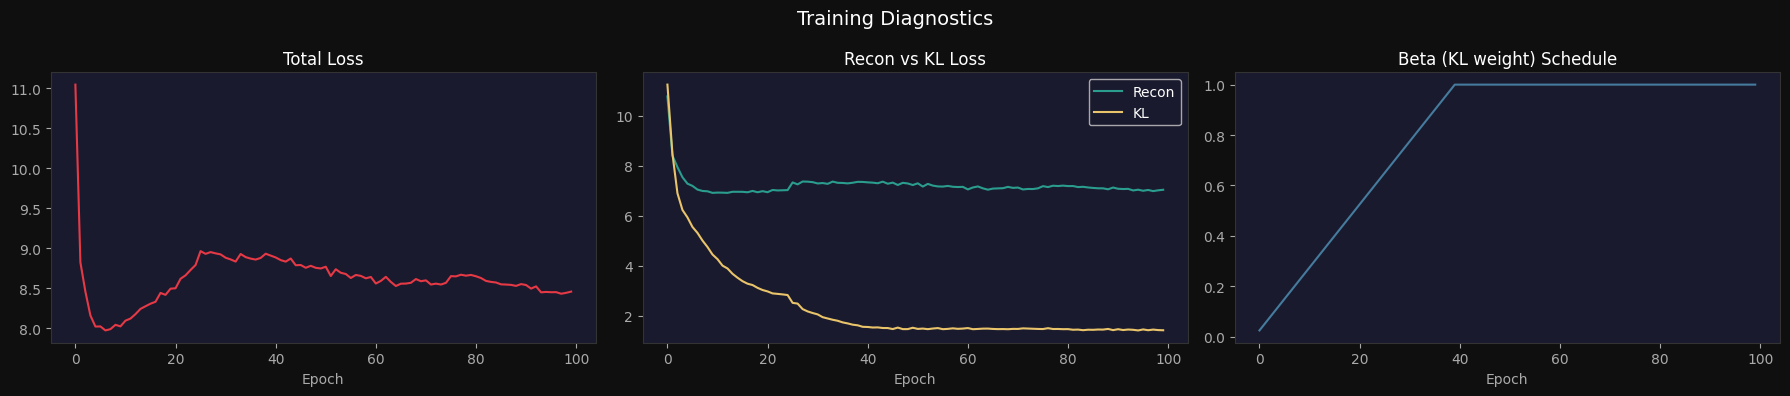

Training curves saved.


In [15]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.patch.set_facecolor('#0f0f0f')
for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

axes[0].plot(loss_history, color='#e63946')
axes[0].set_title('Total Loss', color='white'); axes[0].set_xlabel('Epoch', color='#aaaaaa')

axes[1].plot(recon_history, color='#2a9d8f', label='Recon')
axes[1].plot(kl_history, color='#e9c46a', label='KL')
axes[1].legend(facecolor='#1a1a2e', labelcolor='white')
axes[1].set_title('Recon vs KL Loss', color='white'); axes[1].set_xlabel('Epoch', color='#aaaaaa')

axes[2].plot(beta_history, color='#457b9d')
axes[2].set_title('Beta (KL weight) Schedule', color='white'); axes[2].set_xlabel('Epoch', color='#aaaaaa')

plt.suptitle('Training Diagnostics', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Training curves saved.')

In [16]:
# ── Extract latent representations (use model.eval() + deterministic mean) ───
model.eval()
with torch.no_grad():
    mu_all, logvar_all = model.encode(X_tensor.to(device))
Z_raw = mu_all.cpu().numpy()
print(f'Latent matrix Z_raw: {Z_raw.shape}')

# IMPROVEMENT: Normalize the latent space before clustering
# This is critical — KMeans/Agglomerative assume similar scales across dims
Z_scaler = StandardScaler()
Z = Z_scaler.fit_transform(Z_raw)
print(f'Latent matrix Z (normalized): {Z.shape}')

# Check latent space health
print(f'\nLatent space stats (raw mu):')
print(f'  Mean: {Z_raw.mean():.4f}, Std: {Z_raw.std():.4f}')
print(f'  Mean logvar: {logvar_all.cpu().numpy().mean():.4f}  (healthy if in [-2, 0])')

Latent matrix Z_raw: (1500, 32)
Latent matrix Z (normalized): (1500, 32)

Latent space stats (raw mu):
  Mean: 0.0005, Std: 0.3568
  Mean logvar: -0.2255  (healthy if in [-2, 0])


## 5. Clustering — K-Means · Agglomerative · DBSCAN

**DBSCAN improvement**: Instead of guessing eps=1.5, we use the k-NN distance plot to automatically find a good eps (elbow method).

Auto-tuned DBSCAN eps (90th pct of 5-NN dist): 4.2446


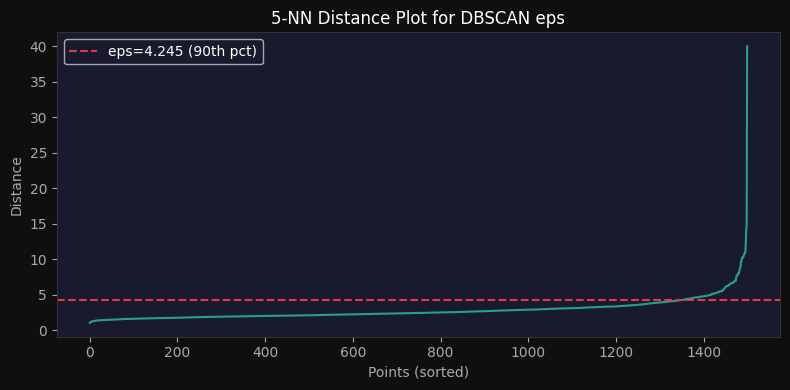

In [17]:
# ── Auto-tune DBSCAN eps via k-NN distance plot ───────────────────────────────
k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors, n_jobs=-1).fit(Z)
distances, _ = nbrs.kneighbors(Z)
knn_dists = np.sort(distances[:, -1])  # k-th neighbor distances

# Elbow: use 90th percentile as eps
eps_auto = np.percentile(knn_dists, 90)
print(f'Auto-tuned DBSCAN eps (90th pct of {k_neighbors}-NN dist): {eps_auto:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0f0f0f'); ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values(): spine.set_edgecolor('#333333')
ax.plot(knn_dists, color='#2a9d8f')
ax.axhline(eps_auto, color='#e63946', ls='--', label=f'eps={eps_auto:.3f} (90th pct)')
ax.set_title(f'{k_neighbors}-NN Distance Plot for DBSCAN eps', color='white')
ax.set_xlabel('Points (sorted)', color='#aaaaaa')
ax.set_ylabel('Distance', color='#aaaaaa')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
plt.savefig('dbscan_eps_tuning.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [18]:
# ── 5A. K-Means ───────────────────────────────────────────────────────────────
# IMPROVEMENT: n_init=20 and more iterations for stable convergence
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20, max_iter=500)
labels_km = km.fit_predict(Z)
print('K-Means done.')

# ── 5B. Agglomerative Clustering ──────────────────────────────────────────────
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
labels_agg = agg.fit_predict(Z)
print('Agglomerative done.')

# ── 5C. DBSCAN with auto-tuned eps ────────────────────────────────────────────
db = DBSCAN(eps=eps_auto, min_samples=k_neighbors, n_jobs=-1)
labels_db = db.fit_predict(Z)
n_db_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_db_noise    = (labels_db == -1).sum()
print(f'DBSCAN done.  Clusters found: {n_db_clusters}  Noise points: {n_db_noise}')

# Encode genre as numeric for ARI
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
genre_labels = le.fit_transform(audio_df['genre'])
print(f'\nGenre label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}')

K-Means done.
Agglomerative done.
DBSCAN done.  Clusters found: 1  Noise points: 91

Genre label mapping: {'Blues': 0, 'Country': 1, 'Electronic': 2, 'Folk': 3, 'Jazz': 4, 'Latin': 5, 'Metal': 6, 'New Age': 7, 'Pop': 8, 'Punk': 9, 'Rap': 10, 'Reggae': 11, 'RnB': 12, 'Rock': 13, 'World': 14}


## 6. Evaluation Metrics (including ARI)

In [19]:
def eval_clustering(Z, labels, name, true_labels=None):
    """
    Compute Silhouette, Davies-Bouldin, Calinski-Harabasz, and ARI scores.
    Noise points (label == -1) are excluded from internal metrics but kept for ARI.
    """
    valid    = labels != -1
    Z_v      = Z[valid]
    labels_v = labels[valid]
    n_unique = len(set(labels_v))
    n_noise  = (labels == -1).sum()

    if n_unique < 2:
        print(f'{name}: only {n_unique} cluster(s) found — skipping metrics.')
        return None

    sil = silhouette_score(Z_v, labels_v)
    db  = davies_bouldin_score(Z_v, labels_v)
    ch  = calinski_harabasz_score(Z_v, labels_v)

    # ARI against genre ground truth
    ari = adjusted_rand_score(true_labels, labels) if true_labels is not None else float('nan')

    print(f'\n── {name} ──')
    print(f'  Clusters          : {n_unique}')
    if n_noise > 0:
        print(f'  Noise points      : {n_noise} (excluded from internal metrics)')
    print(f'  Silhouette Score  : {sil:.5f}   (↑ better, range −1 to 1)')
    print(f'  Davies-Bouldin    : {db:.5f}   (↓ better, min 0)')
    print(f'  Calinski-Harabasz : {ch:.2f}    (↑ better)')
    print(f'  ARI (genre)       : {ari:.5f}   (↑ better, 1=perfect)')

    return {
        'Method':             name,
        'Clusters':           n_unique,
        'Silhouette':         sil,
        'Davies-Bouldin':     db,
        'Calinski-Harabasz':  ch,
        'ARI':                ari,
    }

In [20]:
# ── Run all methods ───────────────────────────────────────────────────────────
results = []
results.append(eval_clustering(Z, labels_km,  f'K-Means (k={N_CLUSTERS})',         true_labels=genre_labels))
results.append(eval_clustering(Z, labels_agg, f'Agglomerative ward (k={N_CLUSTERS})', true_labels=genre_labels))
results.append(eval_clustering(Z, labels_db,  f'DBSCAN (eps={eps_auto:.3f})',       true_labels=genre_labels))

# ── PCA baseline ─────────────────────────────────────────────────────────────
Z_pca_base  = PCA(n_components=32).fit_transform(X_fused)
Z_pca_norm  = StandardScaler().fit_transform(Z_pca_base)
labels_pca  = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20).fit_predict(Z_pca_norm)
results.append(eval_clustering(Z_pca_norm, labels_pca, 'PCA + K-Means (baseline)', true_labels=genre_labels))

# ── Summary table ─────────────────────────────────────────────────────────────
df_results = pd.DataFrame([r for r in results if r is not None]).set_index('Method')
pd.set_option('display.float_format', '{:.4f}'.format)
print('\n====== Clustering Metrics Summary ======')
print(df_results.to_string())

print('\n── Best per metric ──')
print(f'  Silhouette        (↑) : {df_results["Silhouette"].idxmax()}')
print(f'  Davies-Bouldin    (↓) : {df_results["Davies-Bouldin"].idxmin()}')
print(f'  Calinski-Harabasz (↑) : {df_results["Calinski-Harabasz"].idxmax()}')
print(f'  ARI               (↑) : {df_results["ARI"].idxmax()}')


── K-Means (k=15) ──
  Clusters          : 15
  Silhouette Score  : 0.10914   (↑ better, range −1 to 1)
  Davies-Bouldin    : 1.68308   (↓ better, min 0)
  Calinski-Harabasz : 115.56    (↑ better)
  ARI (genre)       : 0.04924   (↑ better, 1=perfect)

── Agglomerative ward (k=15) ──
  Clusters          : 15
  Silhouette Score  : 0.06676   (↑ better, range −1 to 1)
  Davies-Bouldin    : 1.90490   (↓ better, min 0)
  Calinski-Harabasz : 96.09    (↑ better)
  ARI (genre)       : 0.04742   (↑ better, 1=perfect)
DBSCAN (eps=4.245): only 1 cluster(s) found — skipping metrics.

── PCA + K-Means (baseline) ──
  Clusters          : 15
  Silhouette Score  : 0.00716   (↑ better, range −1 to 1)
  Davies-Bouldin    : 2.96530   (↓ better, min 0)
  Calinski-Harabasz : 22.54    (↑ better)
  ARI (genre)       : 0.04311   (↑ better, 1=perfect)

====== Clustering Metrics Summary ======
                           Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI
Method                       

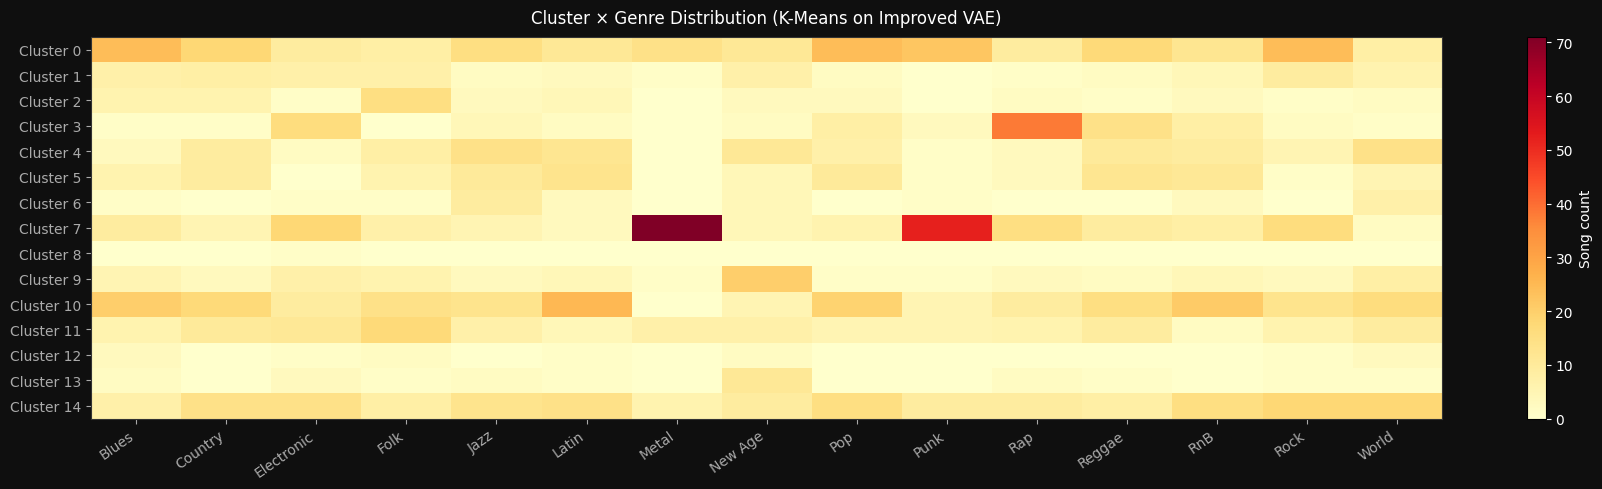

Genre heatmap saved.


In [21]:
# ── Cluster × Genre heatmap ───────────────────────────────────────────────────
df_cg = pd.DataFrame({'cluster': labels_km, 'genre': audio_df['genre']})
ct    = pd.crosstab(df_cg['cluster'], df_cg['genre'])

genre_names = audio_df['genre'].unique()
fig, ax = plt.subplots(figsize=(max(8, len(genre_names) * 1.2), 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

im = ax.imshow(ct.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=35, ha='right', color='#aaaaaa')
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels([f'Cluster {i}' for i in ct.index], color='#aaaaaa')
ax.set_title('Cluster × Genre Distribution (K-Means on Improved VAE)', color='white', pad=10)

cb = plt.colorbar(im, ax=ax)
cb.set_label('Song count', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

plt.tight_layout()
plt.savefig('cluster_genre_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Genre heatmap saved.')

## 7. Latent Space Visualisation — UMAP + t-SNE

IndexError: list index out of range

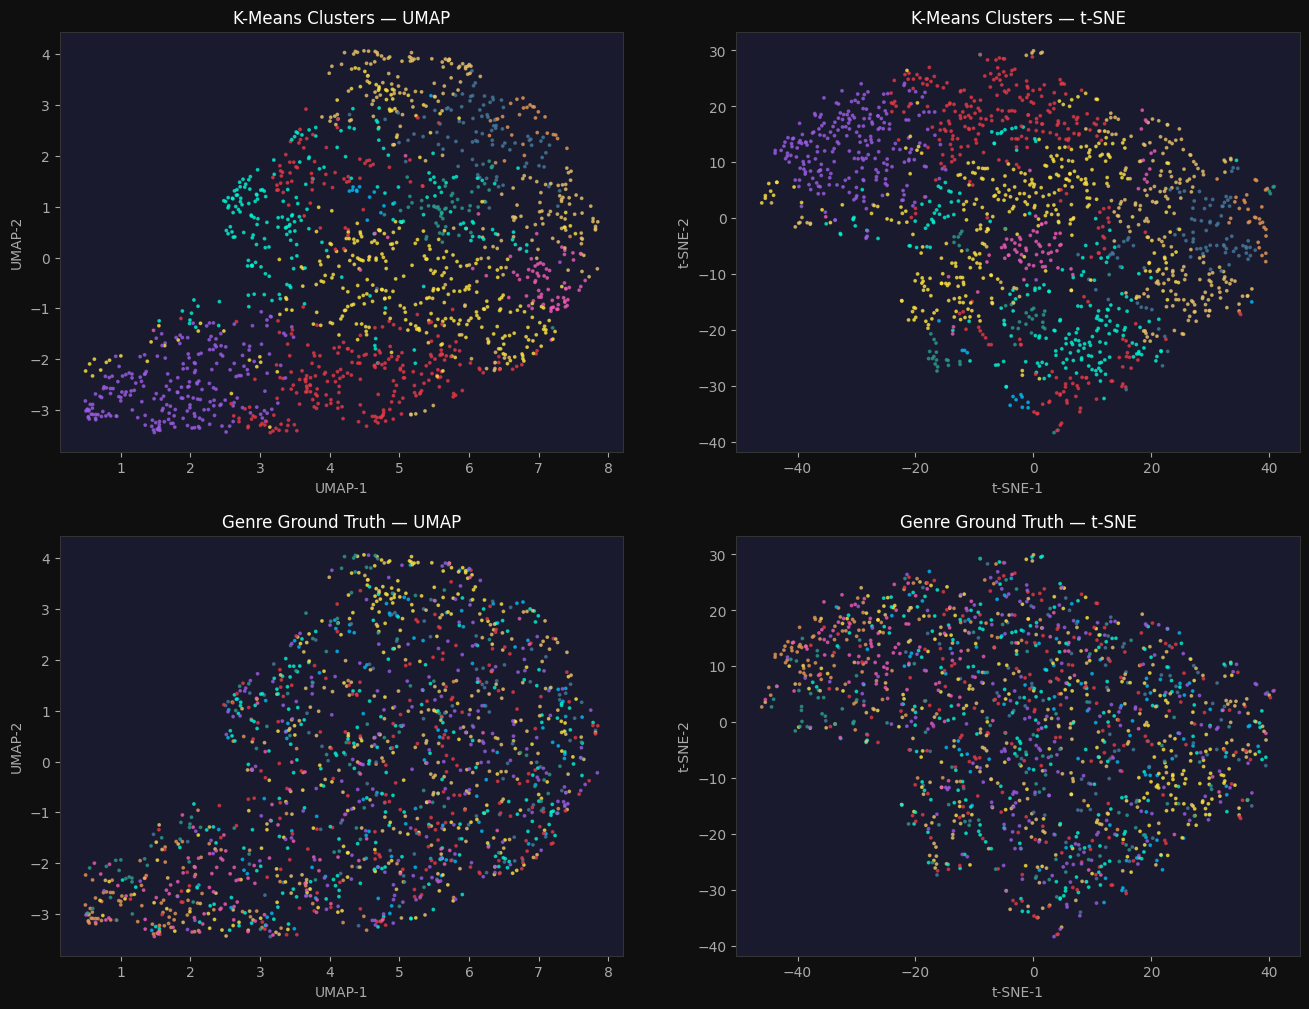

In [22]:
palette  = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#e69956',
            '#9b5de5', '#f15bb5', '#fee440', '#00bbf9', '#00f5d4']
cmap_cls = mcolors.ListedColormap(palette[:N_CLUSTERS])

# UMAP
reducer = umap_lib.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
Z_umap  = reducer.fit_transform(Z)

# t-SNE
Z_tsne = TSNE(n_components=2, random_state=42, perplexity=40, learning_rate='auto',
               init='pca').fit_transform(Z)  # PCA init is more stable

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0f0f0f')
for ax in axes.flat:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# Row 1: K-Means cluster labels
axes[0,0].scatter(Z_umap[:,0], Z_umap[:,1], c=labels_km, cmap=cmap_cls, s=3, alpha=0.7)
axes[0,0].set_title('K-Means Clusters — UMAP', color='white', fontsize=12)
axes[0,0].set_xlabel('UMAP-1', color='#aaaaaa'); axes[0,0].set_ylabel('UMAP-2', color='#aaaaaa')

axes[0,1].scatter(Z_tsne[:,0], Z_tsne[:,1], c=labels_km, cmap=cmap_cls, s=3, alpha=0.7)
axes[0,1].set_title('K-Means Clusters — t-SNE', color='white', fontsize=12)
axes[0,1].set_xlabel('t-SNE-1', color='#aaaaaa'); axes[0,1].set_ylabel('t-SNE-2', color='#aaaaaa')

# Row 2: Genre ground-truth labels
scatter_umap = axes[1,0].scatter(Z_umap[:,0], Z_umap[:,1], c=genre_labels,
                                  cmap=cmap_cls, s=3, alpha=0.7)
axes[1,0].set_title('Genre Ground Truth — UMAP', color='white', fontsize=12)
axes[1,0].set_xlabel('UMAP-1', color='#aaaaaa'); axes[1,0].set_ylabel('UMAP-2', color='#aaaaaa')

axes[1,1].scatter(Z_tsne[:,0], Z_tsne[:,1], c=genre_labels,
                  cmap=cmap_cls, s=3, alpha=0.7)
axes[1,1].set_title('Genre Ground Truth — t-SNE', color='white', fontsize=12)
axes[1,1].set_xlabel('t-SNE-1', color='#aaaaaa'); axes[1,1].set_ylabel('t-SNE-2', color='#aaaaaa')

# Add genre legend
legend_handles = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=palette[i], markersize=8, label=g)
    for i, g in enumerate(le.classes_)
]
axes[1,1].legend(handles=legend_handles, loc='best', facecolor='#0f0f0f',
                 labelcolor='white', fontsize=8)

plt.suptitle('Improved HybridVAE Latent Space — Clusters vs Genre Labels',
             color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('hybrid_vae_latent_vis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Latent space visualisation saved.')

## 8. Clustering Method Comparison Bar Chart

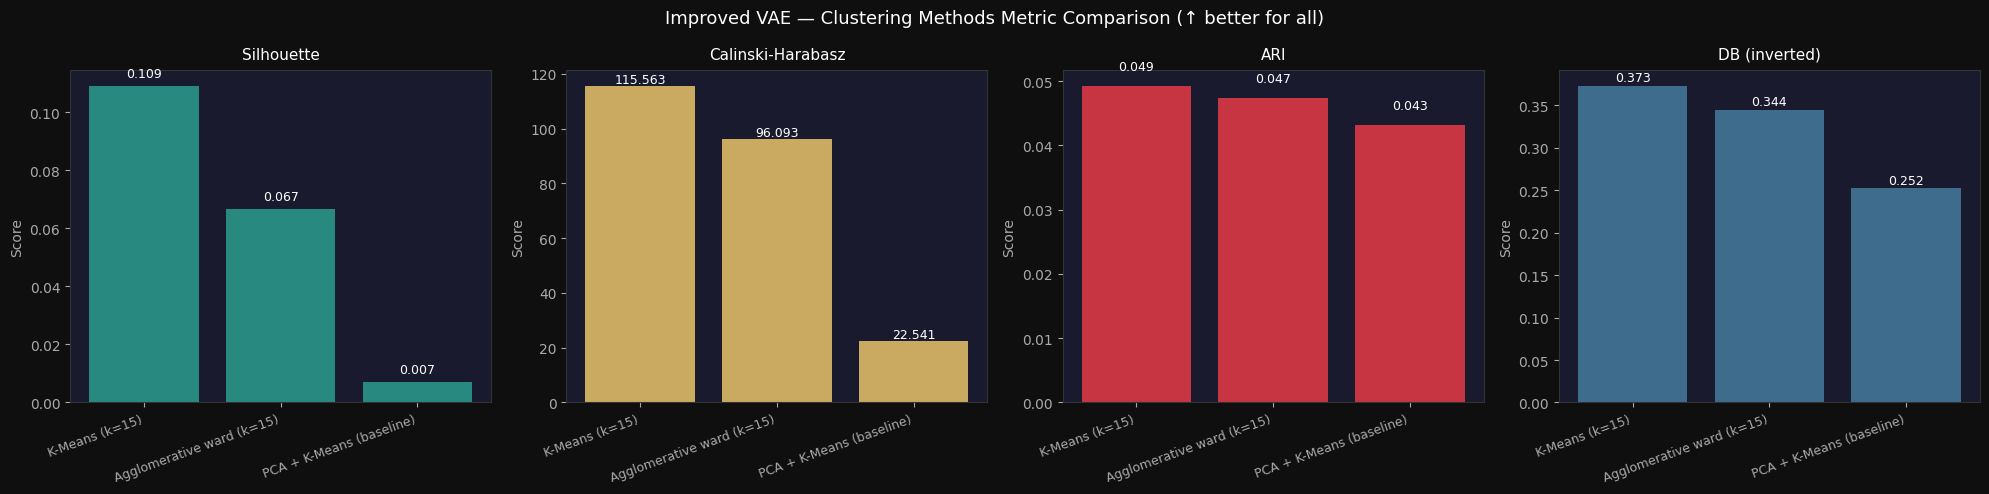

Comparison chart saved.


In [26]:
df_plot = df_results[['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'ARI']].copy()
df_plot['DB (inverted)'] = 1 / (1 + df_plot['Davies-Bouldin'])
df_plot_show = df_plot.drop(columns='Davies-Bouldin')

bar_colors = ['#2a9d8f', '#e9c46a', '#e63946', '#457b9d']
fig, axes  = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('#0f0f0f')

for ax, col, color in zip(axes, df_plot_show.columns, bar_colors):
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

    vals = df_plot_show[col]
    bars = ax.bar(range(len(vals)), vals, color=color, alpha=0.85, edgecolor='none')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha='right', color='#aaaaaa', fontsize=9)
    ax.set_title(col, color='white', fontsize=11, pad=8)
    ax.set_ylabel('Score', color='#aaaaaa')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', color='white', fontsize=9)

plt.suptitle('Improved VAE — Clustering Methods Metric Comparison (↑ better for all)',
             color='white', fontsize=13)
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Comparison chart saved.')

## 9. Qualitative: Top TF-IDF Words per Cluster

In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())

print('=' * 65)
print('TOP 15 TF-IDF WORDS PER CLUSTER  (K-Means on Improved HybridVAE latent)')
print('=' * 65)

for c in range(N_CLUSTERS):
    mask       = labels_km == c
    mean_tfidf = lyrics_feats[mask].mean(axis=0)
    top_idx    = mean_tfidf.argsort()[::-1][:15]
    top_words  = feature_names[top_idx].tolist()
    print(f'\nCluster {c}  ({mask.sum():,} songs)')
    print('  ' + ',  '.join(top_words))

print('\n')
print('=' * 65)
print('CLUSTER SIZE SUMMARY')
print('=' * 65)
unique, counts = np.unique(labels_km, return_counts=True)
for c, cnt in zip(unique, counts):
    pct = cnt / len(labels_km) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {c}: {cnt:5,} songs  ({pct:.1f}%)  {bar}')